In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from scipy.stats import pearsonr
from scipy.signal import resample_poly

# Enable inline plotting.
%matplotlib inline

In [14]:
# Automatically retrieve folder names.
def get_subfolders(folder_path):
    """Return the names of all subfolders in the specified folder."""
    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"Folder does not exist: {folder_path}")
    subfolders = [
        name for name in os.listdir(folder_path)
        if os.path.isdir(os.path.join(folder_path, name))
    ]
    return subfolders

# Define the Min-Max normalization function.
def min_max_normalize(df, feature_range=(0, 1)):
    """Normalize each DataFrame column to the specified range."""
    df_normalized = df.copy()
    min_val, max_val = feature_range
    for col in df.columns:
        col_min = df[col].min()
        col_max = df[col].max()
        if col_max == col_min:
            df_normalized[col] = min_val
        else:
            df_normalized[col] = (df[col] - col_min) * (max_val - min_val) / (col_max - col_min) + min_val
    return df_normalized

def downsample_data(df, source_fs=25):
    if source_fs not in (20, 25, 30):
        raise ValueError("source_fs must be 20, 25, or 30")

    columns = ["unit_id", "t", "value"]
    results = []

    for unit_id, group in df.sort_values(["unit_id", "t"]).groupby(
        "unit_id", sort=False, observed=True
    ):
        if source_fs in (20, 30):
            # 20 Hz: average every 2 frames; 30 Hz: average every 3 frames.
            factor = source_fs // 10
            group_index = (group["t"] - group["t"].min()) // factor
            sampled = group.groupby(group_index)["value"].mean().to_numpy()

        else:
            # 25 Hz: apply an anti-aliasing FIR filter and resample by a factor of 2/5.
            times = group["t"].to_numpy(dtype=float)
            values = group["value"].to_numpy(dtype=float)

            if not (np.isfinite(times).all() and np.isfinite(values).all()):
                raise ValueError(
                    f"unit_id={unit_id}: t or value contains NaN or infinite values"
                )

            if not np.allclose(np.diff(times), 1.0, rtol=1e-5, atol=1e-8):
                raise ValueError(
                    f"unit_id={unit_id}: Original frame indices are nonconsecutive or contain duplicates"
                )

            sampled = (
                resample_poly(values, up=2, down=5, padtype="line")
                if len(values) > 1
                else values.copy()
            )

        # For each unit_id, frame indices start independently at 0 and increase by 1.
        result = pd.DataFrame({
            "t": np.arange(len(sampled)),
            "value": sampled,
        })
        result.insert(0, "unit_id", unit_id)
        results.append(result)

    if not results:
        return df.loc[:, columns].iloc[:0].copy()

    return pd.concat(results, ignore_index=True).loc[:, columns]

Selected folders: ['5']


C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\2332506466.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_signal = df.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)
d:\software\anaconda3\envs\M2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



>>> [5] Starting module 1: running 100 independent training runs and decoding metric evaluations for the experimental group...


d:\software\anaconda3\envs\M2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\software\anaconda3\envs\M2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\software\anaconda3\envs\M2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\software\anaconda3\envs\M2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_sh

    -> Experimental group progress: 20/100 completed.


...

d:\software\anaconda3\envs\M2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\software\anaconda3\envs\M2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\software\anaconda3\envs\M2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\software\anaconda3\envs\M2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_sh

    -> Control group progress: 80/100 completed.


d:\software\anaconda3\envs\M2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\software\anaconda3\envs\M2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\software\anaconda3\envs\M2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
d:\software\anaconda3\envs\M2\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_sh

    -> Control group progress: 100/100 completed.

    -> Results summary | Experimental group mean R²: -2.0286, mean r: 0.1167
    -> Results summary | Control group mean R²: -1.6878, mean r: 0.0473


C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\2332506466.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='R2_Score', data=df_plot, palette=['#4C72B0', '#C44E52'],
C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\2332506466.py:211: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Group', y='R2_Score', data=df_plot, palette=['#4C72B0', '#C44E52'],
C:\Users\Admin\AppData\Local\Temp\ipykernel_3800\2332506466.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Pearson_r', data=df_plot, palette=['#4C72B0', '

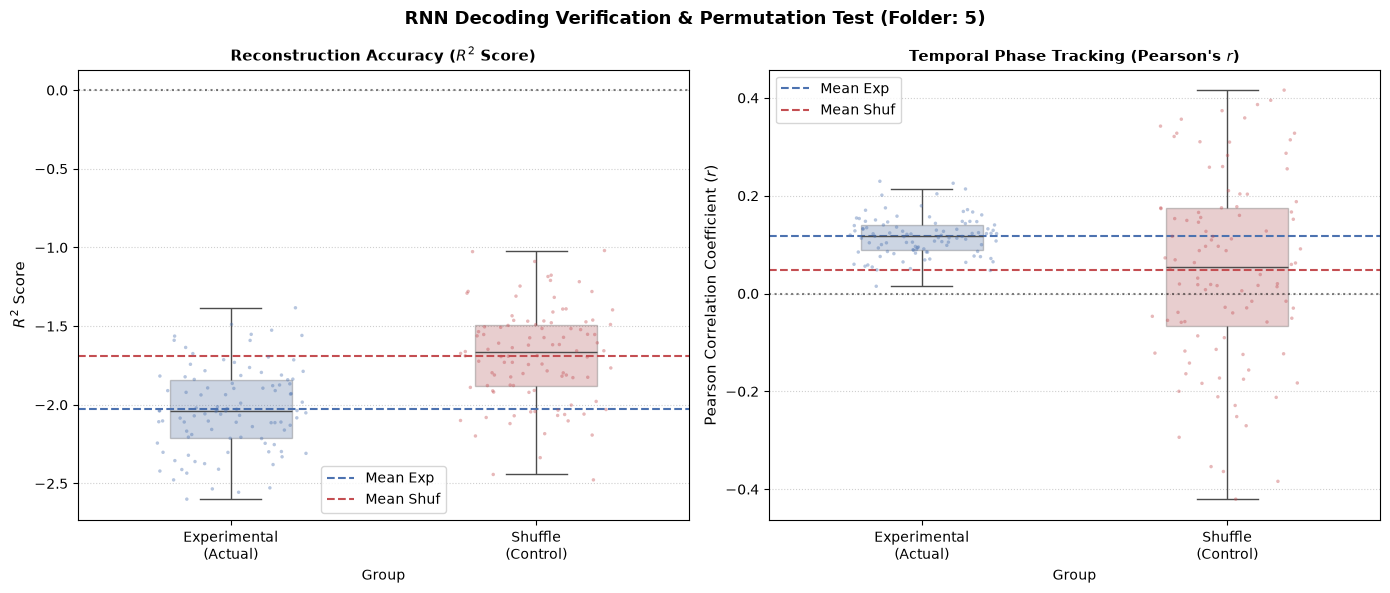

>>> [5] The two-panel figure and the complete 200-row statistics CSV have been saved to: D:\RQ\M2 Project\summary\20260903 RNN Curve Fitting batch two shuffle\CamkII TST\5\RNN


In [ ]:
path_signal = r'D:\XJN\behavior_signaling\CamkII TST'
savepath = r'D:\RQ\M2 Project\summary\20260903 RNN Curve Fitting batch two shuffle\CamkII TST'
fig_path = savepath

# ============================================================
# Select the folders to process (folder names are numeric).
# Set to None to process all folders, or use a list to process only the specified folders.
# Example: selected_folders = ['1', '3', '5'] or selected_folders = None
# CamkII TST 20Hz 1,2,3,4,6,7,8,9,10
# Hsyn 20Hz 1,2,3,4,5
# PV 20Hz 1,2,3,4,7
# VIP 20Hz 1,2,3,4,6
# VIP 30Hz 5,7,8
# SST 30Hz 4, 5
# PV 25Hz 5, 6
# CamkII TST 25Hz 5

selected_folders = ['5']  # <-- Modify as needed.
# ============================================================

subfolders = get_subfolders(path_signal)

if selected_folders is not None:
    subfolders = [f for f in subfolders if f in selected_folders]
    print(f'Selected folders: {subfolders}')

for folder in subfolders:
    folder_path = os.path.join(path_signal, folder)
    savefolder = os.path.join(savepath, folder, 'RNN')
    if not os.path.exists(savefolder):
        os.makedirs(savefolder)
    fig_path = savefolder

    # Read the data.
    df_signal = pd.read_csv(folder_path+'\\save_result\\C.csv')
    df_raw = pd.read_csv(folder_path+'\\save_result\\YrA.csv')
    df_behaviour = pd.read_csv(folder_path+'\\Area_Change.csv')
    
    # Standardize column names.
    df_signal = df_signal.rename(columns={"unit_id":"unit_id","frame":"t","C":"value"})
    df_raw = df_raw.rename(columns={"unit_id":"unit_id","frame":"t","YrA":"value"})

    # Step 1: Manually define the list of IDs to exclude.
    drop_list = []  # <-- Manually identified anomalous IDs; modify as needed.

    # Step 2: Identify valid IDs using C as the reference.
    valid_ids = set(df_signal['unit_id'].unique()) - set(drop_list)

    # Step 3: Retain valid IDs in YrA and C.
    df_raw = df_raw[df_raw['unit_id'].isin(valid_ids)].copy()
    df_signal = df_signal[df_signal['unit_id'].isin(valid_ids)].copy()

    # Step 4: Reassign consecutive IDs.
    new_id_map = {old_id: new_id for new_id, old_id in enumerate(sorted(valid_ids))}
    df_raw['unit_id'] = df_raw['unit_id'].map(new_id_map)
    df_signal['unit_id'] = df_signal['unit_id'].map(new_id_map)

# ============================================================
    df_raw = downsample_data(df_raw, source_fs=25)
    df_signal = downsample_data(df_signal, source_fs=25)
# ============================================================

    # Standardize C.
    df = pd.merge(df_raw, df_signal, on=['unit_id', 't'], suffixes=('_YrA', '_C'))
    df['residual'] = df['value_YrA'] - df['value_C']
    df['value_z'] = df['value_C'] / df.groupby('unit_id')['residual'].transform('std')

    # Truncate the behavioral and signal data to the shortest frame count.
    df_behaviour = df_behaviour.T.reset_index(drop=True)
    min_len = min(df.groupby('unit_id').size().min(), len(df_behaviour))

    df_signal = df.groupby('unit_id').apply(lambda g: g.sort_values('t').head(min_len)).reset_index(drop=True)
    resized_df_signal_dic_update = df_signal.pivot(index='t', columns='unit_id', values='value_z').reset_index(drop=True)
    df_behaviour_update = df_behaviour[:min_len]

    # Normalize both DataFrames.
    df_signal_normalized = min_max_normalize(resized_df_signal_dic_update)
    df_behaviour_normalized = min_max_normalize(df_behaviour_update)

    # Use a strictly chronological split to prevent temporal leakage (shuffle=False).
    S_train, S_test, B_train, B_test = train_test_split(df_signal_normalized,
                                                        df_behaviour_normalized,
                                                        test_size=0.2,
                                                        random_state=0,
                                                        shuffle=False)
    
    S_train = S_train.reset_index().drop(columns={'index'})
    S_test = S_test.reset_index().drop(columns={'index'})
    B_train = B_train.reset_index().drop(columns={'index'})
    B_test = B_test.reset_index().drop(columns={'index'})

    # =========================================================================
    # Main evaluation pipeline: R2, Pearson r, and p-value.
    # =========================================================================
    
    # Run configuration
    ITERATIONS = 100        
    FIT_EPOCHS = 30          # 30 epochs are recommended to balance convergence and overall computational efficiency.
    time_steps = 1           # Fix time_steps at 1.
    
    n_features_train = S_train.shape[1]
    n_features_test = S_test.shape[1]
    
    # Prepare the base training and test data.
    n_samples_train = S_train.shape[0] // time_steps
    n_samples_test = S_test.shape[0] // time_steps
    
    S_train_rnn_base = S_train.values[:n_samples_train * time_steps].reshape(n_samples_train, time_steps, n_features_train)
    S_test_rnn_base = S_test.values[:n_samples_test * time_steps].reshape(n_samples_test, time_steps, n_features_test)
    
    # Flatten the ground-truth test values into a 1D array for Pearson correlation calculations.
    B_train_base = B_train.values[:n_samples_train * time_steps]
    B_test_base = B_test.values[:n_samples_test * time_steps]
    B_test_base_flat = B_test_base.flatten()

    # Initialize lists for experimental group metrics.
    experimental_r2_scores = []
    experimental_r_values = []
    experimental_p_values = []
    
    # Initialize lists for control group metrics.
    shuffle_r2_scores = []
    shuffle_r_values = []
    shuffle_p_values = []

    # -------------------------------------------------------------------------
    # Part 1: 100 reconstruction evaluations for the experimental group.
    # -------------------------------------------------------------------------
    print(f"\n>>> [{folder}] Starting module 1: running {ITERATIONS} independent training runs and decoding metric evaluations for the experimental group...")
    for i in range(ITERATIONS):
        model_exp = Sequential()
        model_exp.add(SimpleRNN(units=50, input_shape=(time_steps, n_features_train), activation='relu'))
        model_exp.add(Dense(units=1, activation='softplus'))
        model_exp.compile(optimizer='adam', loss='mean_squared_error')
        
        # Fit the model with verbose output disabled.
        model_exp.fit(S_train_rnn_base, B_train_base, epochs=FIT_EPOCHS, batch_size=32, verbose=0)
        
        # Generate predictions and flatten them.
        pred_exp = model_exp.predict(S_test_rnn_base, verbose=0)
        pred_exp_flat = pred_exp.flatten()
        
        # Compute the three primary statistics.
        r2 = r2_score(B_test_base, pred_exp)
        r_val, p_val = pearsonr(B_test_base_flat, pred_exp_flat)
        
        experimental_r2_scores.append(r2)
        experimental_r_values.append(r_val)
        experimental_p_values.append(p_val)
        
        if (i + 1) % (ITERATIONS // 5) == 0:
            print(f"    -> Experimental group progress: {i + 1}/{ITERATIONS} completed.")

    # -------------------------------------------------------------------------
    # Part 2: 100 permutation evaluations for the shuffle control group.
    # -------------------------------------------------------------------------
    print(f"\n>>> [{folder}] Starting module 2: running {ITERATIONS} permutation trials with temporally shuffled neural and behavioral data for the control group...")
    for i in range(ITERATIONS):
        # Independently shuffle both neural and behavioral data at the frame level.
        s_shuffle_indices = np.random.permutation(len(S_train))
        b_shuffle_indices = np.random.permutation(len(B_train))
        
        S_train_shuffled = S_train.iloc[s_shuffle_indices].reset_index(drop=True)
        B_train_shuffled = B_train.iloc[b_shuffle_indices].reset_index(drop=True)
        
        S_train_rnn_shuf = S_train_shuffled.values[:n_samples_train * time_steps].reshape(n_samples_train, time_steps, n_features_train)
        B_train_rnn_shuf = B_train_shuffled.values[:n_samples_train * time_steps]
        
        model_shuf = Sequential()
        model_shuf.add(SimpleRNN(units=50, input_shape=(time_steps, n_features_train), activation='relu'))
        model_shuf.add(Dense(units=1, activation='softplus'))
        model_shuf.compile(optimizer='adam', loss='mean_squared_error')
        
        model_shuf.fit(S_train_rnn_shuf, B_train_rnn_shuf, epochs=FIT_EPOCHS, batch_size=32, verbose=0)
        
        # Evaluate on the original, unshuffled test set.
        pred_shuf = model_shuf.predict(S_test_rnn_base, verbose=0)
        pred_shuf_flat = pred_shuf.flatten()
        
        # Compute the three primary statistics.
        r2_shuf = r2_score(B_test_base, pred_shuf)
        r_val_shuf, p_val_shuf = pearsonr(B_test_base_flat, pred_shuf_flat)
        
        shuffle_r2_scores.append(r2_shuf)
        shuffle_r_values.append(r_val_shuf)
        shuffle_p_values.append(p_val_shuf)
        
        if (i + 1) % (ITERATIONS // 5) == 0:
            print(f"    -> Control group progress: {i + 1}/{ITERATIONS} completed.")

    # Compute mean metrics across all runs.
    print(f"\n    -> Results summary | Experimental group mean R²: {np.mean(experimental_r2_scores):.4f}, mean r: {np.mean(experimental_r_values):.4f}")
    print(f"    -> Results summary | Control group mean R²: {np.mean(shuffle_r2_scores):.4f}, mean r: {np.mean(shuffle_r_values):.4f}")

    # -------------------------------------------------------------------------
    # Part 3: create a publication-quality two-panel figure (Panel A: R2 comparison; Panel B: Pearson r comparison).
    # -------------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Assemble a long-format DataFrame for plotting.
    df_plot = pd.DataFrame({
        'R2_Score': experimental_r2_scores + shuffle_r2_scores,
        'Pearson_r': experimental_r_values + shuffle_r_values,
        'Group': ['Experimental\n(Actual)'] * ITERATIONS + ['Shuffle\n(Control)'] * ITERATIONS
    })
    
    # --- Left panel: box and scatter plots of R2 scores. ---
    sns.boxplot(x='Group', y='R2_Score', data=df_plot, palette=['#4C72B0', '#C44E52'], 
                width=0.4, showfliers=False, boxprops=dict(alpha=0.3), ax=axes[0])
    sns.stripplot(x='Group', y='R2_Score', data=df_plot, palette=['#4C72B0', '#C44E52'], 
                  alpha=0.4, jitter=0.25, size=2.5, ax=axes[0])
    axes[0].axhline(y=np.mean(experimental_r2_scores), color='#4C72B0', linestyle='--', linewidth=1.5, label='Mean Exp')
    axes[0].axhline(y=np.mean(shuffle_r2_scores), color='#C44E52', linestyle='--', linewidth=1.5, label='Mean Shuf')
    axes[0].axhline(y=0, color='black', linestyle=':', alpha=0.5)
    axes[0].set_title('Reconstruction Accuracy ($R^2$ Score)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('$R^2$ Score', fontsize=11)
    axes[0].grid(True, axis='y', linestyle=':', alpha=0.6)
    axes[0].legend(loc='best')
    
    # --- Right panel: box and scatter plots of Pearson correlation coefficients. ---
    sns.boxplot(x='Group', y='Pearson_r', data=df_plot, palette=['#4C72B0', '#C44E52'], 
                width=0.4, showfliers=False, boxprops=dict(alpha=0.3), ax=axes[1])
    sns.stripplot(x='Group', y='Pearson_r', data=df_plot, palette=['#4C72B0', '#C44E52'], 
                  alpha=0.4, jitter=0.25, size=2.5, ax=axes[1])
    axes[1].axhline(y=np.mean(experimental_r_values), color='#4C72B0', linestyle='--', linewidth=1.5, label='Mean Exp')
    axes[1].axhline(y=np.mean(shuffle_r_values), color='#C44E52', linestyle='--', linewidth=1.5, label='Mean Shuf')
    axes[1].axhline(y=0, color='black', linestyle=':', alpha=0.5)
    axes[1].set_title('Temporal Phase Tracking (Pearson\'s $r$)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Pearson Correlation Coefficient ($r$)', fontsize=11)
    axes[1].grid(True, axis='y', linestyle=':', alpha=0.6)
    axes[1].legend(loc='best')
    
    plt.suptitle(f'RNN Decoding Verification & Permutation Test (Folder: {folder})', fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig(os.path.join(savefolder, 'rnn_comprehensive_metrics_comparison.png'), dpi=300)
    plt.show()
    plt.close()
    
    # -------------------------------------------------------------------------
    # Part 4: save all quantitative metrics (R2, r, and p-value for every run).
    # -------------------------------------------------------------------------
    df_metrics_output = pd.DataFrame({
        'iteration': range(1, ITERATIONS + 1),
        'experimental_r2_score': experimental_r2_scores,
        'experimental_r_value': experimental_r_values,
        'experimental_p_value': experimental_p_values,
        'shuffle_r2_score': shuffle_r2_scores,
        'shuffle_r_value': shuffle_r_values,
        'shuffle_p_value': shuffle_p_values
    })
    df_metrics_output.to_csv(os.path.join(savefolder, 'rnn_full_statistical_distributions.csv'), index=False)
    
    print(f">>> [{folder}] The two-panel figure and the complete 200-row statistics CSV have been saved to: {savefolder}\n" + "="*60)